# 3.3 Lab: Implementing Logistic Regression

## Table of Contents
- [3.3.1 Setup and Data Preparation](#331-setup-and-data-preparation)
- [3.3.2 Exploratory Data Analysis](#332-exploratory-data-analysis)
- [3.3.3 Feature Scaling](#333-feature-scaling)
- [3.3.4 Model Training](#334-model-training)
- [3.3.5 Making Predictions](#335-making-predictions)
- [3.3.6 Basic Evaluation](#336-basic-evaluation)
- [3.3.7 Model Interpretation](#337-model-interpretation)
- [3.3.8 Visualization of Decision Boundary](#338-visualization-of-decision-boundary)
- [3.3.9 Experimenting with Thresholds](#339-experimenting-with-thresholds)

## 3.3.1 Setup and Data Preparation

In this lab, we'll implement Logistic Regression for a binary classification task using Scikit-learn. We'll use the **Breast Cancer Wisconsin (Diagnostic) dataset**, which is included in Scikit-learn. The task is to predict whether a tumor is malignant or benign based on features derived from digitized images of fine needle aspirates (FNA) of breast mass.

Let's start by importing the necessary libraries and loading the dataset:

In [1]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler

# Set seed for reproducibility
np.random.seed(42)

print("Libraries imported successfully.")

Libraries imported successfully.


Now let's load the dataset and create a DataFrame for easier exploration:

In [2]:
# Load the breast cancer dataset
cancer = load_breast_cancer()
cancer

{'data': array([[1.799e+01, 1.038e+01, 1.228e+02, ..., 2.654e-01, 4.601e-01,
         1.189e-01],
        [2.057e+01, 1.777e+01, 1.329e+02, ..., 1.860e-01, 2.750e-01,
         8.902e-02],
        [1.969e+01, 2.125e+01, 1.300e+02, ..., 2.430e-01, 3.613e-01,
         8.758e-02],
        ...,
        [1.660e+01, 2.808e+01, 1.083e+02, ..., 1.418e-01, 2.218e-01,
         7.820e-02],
        [2.060e+01, 2.933e+01, 1.401e+02, ..., 2.650e-01, 4.087e-01,
         1.240e-01],
        [7.760e+00, 2.454e+01, 4.792e+01, ..., 0.000e+00, 2.871e-01,
         7.039e-02]]),
 'target': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
        0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
        1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
        1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
        1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0

In [4]:
# Create a DataFrame for easier exploration
df = pd.DataFrame(cancer.data, columns=cancer.feature_names)
df['target'] = cancer.target  # 0: malignant, 1: benign

In [5]:
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [6]:
print("\nDataset loaded successfully.")
print("Dataset shape:", df.shape)
print("Target names:", list(cancer.target_names))  # Shows what 0 and 1 represent
print("\nClass distribution (0=Malignant, 1=Benign):")
print(df['target'].value_counts())
print(df['target'].value_counts(normalize=True).round(3))  # Show proportions


Dataset loaded successfully.
Dataset shape: (569, 31)
Target names: ['malignant', 'benign']

Class distribution (0=Malignant, 1=Benign):
target
1    357
0    212
Name: count, dtype: int64
target
1    0.627
0    0.373
Name: proportion, dtype: float64


Let's examine the first few rows to understand the structure of the data:

In [8]:
# Display the first 5 rows
print("\nFirst 5 rows of the dataset:")
df.head()


First 5 rows of the dataset:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [9]:
# Summary information about the dataset
print("\nDataset Info:")
df.info()


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness 

In [11]:
# Statistical summary of the features
print("\nStatistical Summary:")
df.describe().round(2).T


Statistical Summary:


,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.13,3.52,6.98,11.70,13.37,15.78,28.11
mean texture,569.0,19.29,4.30,9.71,16.17,18.84,21.80,39.28
mean perimeter,569.0,91.97,24.30,43.79,75.17,86.24,104.10,188.50
mean area,569.0,654.89,351.91,143.50,420.30,551.10,782.70,2501.00
mean smoothness,569.0,0.10,0.01,0.05,0.09,0.10,0.11,0.16
mean compactness,569.0,0.10,0.05,0.02,0.06,0.09,0.13,0.35
mean concavity,569.0,0.09,0.08,0.00,0.03,0.06,0.13,0.43
mean concave points,569.0,0.05,0.04,0.00,0.02,0.03,0.07,0.20
mean symmetry,569.0,0.18,0.03,0.11,0.16,0.18,0.20,0.30
mean fractal dimension,569.0,0.06,0.01,0.05,0.06,0.06,0.07,0.10


## 3.3.2 Exploratory Data Analysis

Before building our model, let's perform some exploratory data analysis to better understand the dataset:

In [12]:
# Check for missing values
print("\nMissing values per column:")
print(df.isnull().sum())


Missing values per column:
mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target                     0
dtype: int64


<Figure size 1500x1000 with 0 Axes>

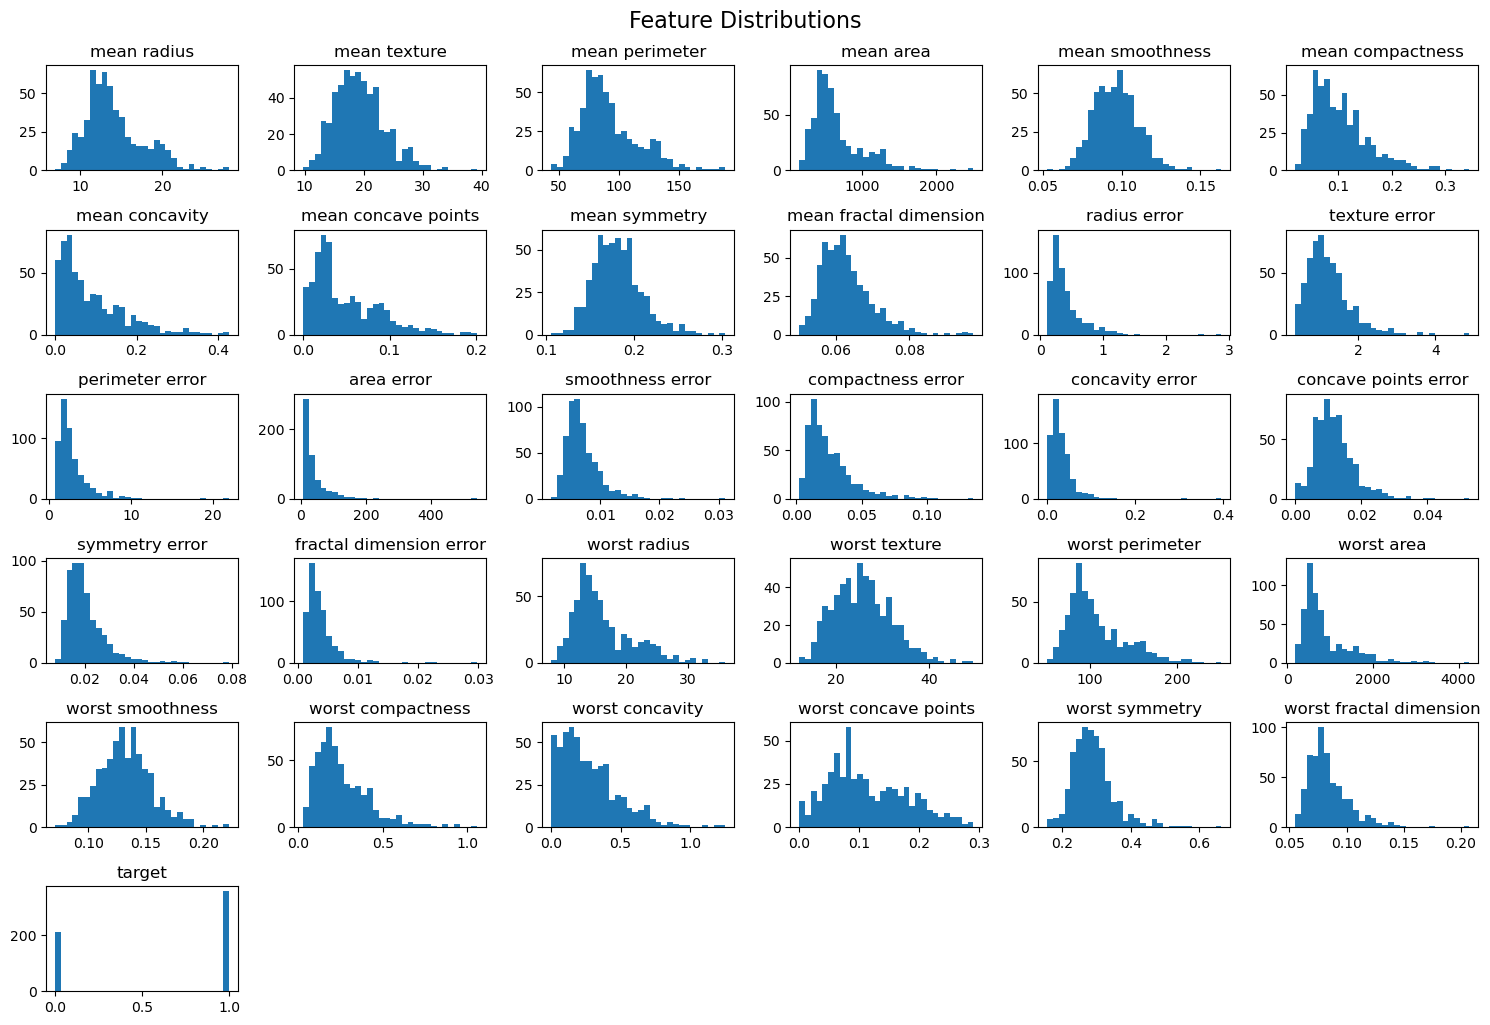

In [13]:
# Analyze the distribution of features
plt.figure(figsize=(15, 10))
df.hist(bins=30, figsize=(15, 10), grid=False)
plt.tight_layout()
plt.suptitle('Feature Distributions', y=1.02, fontsize=16)
plt.show()

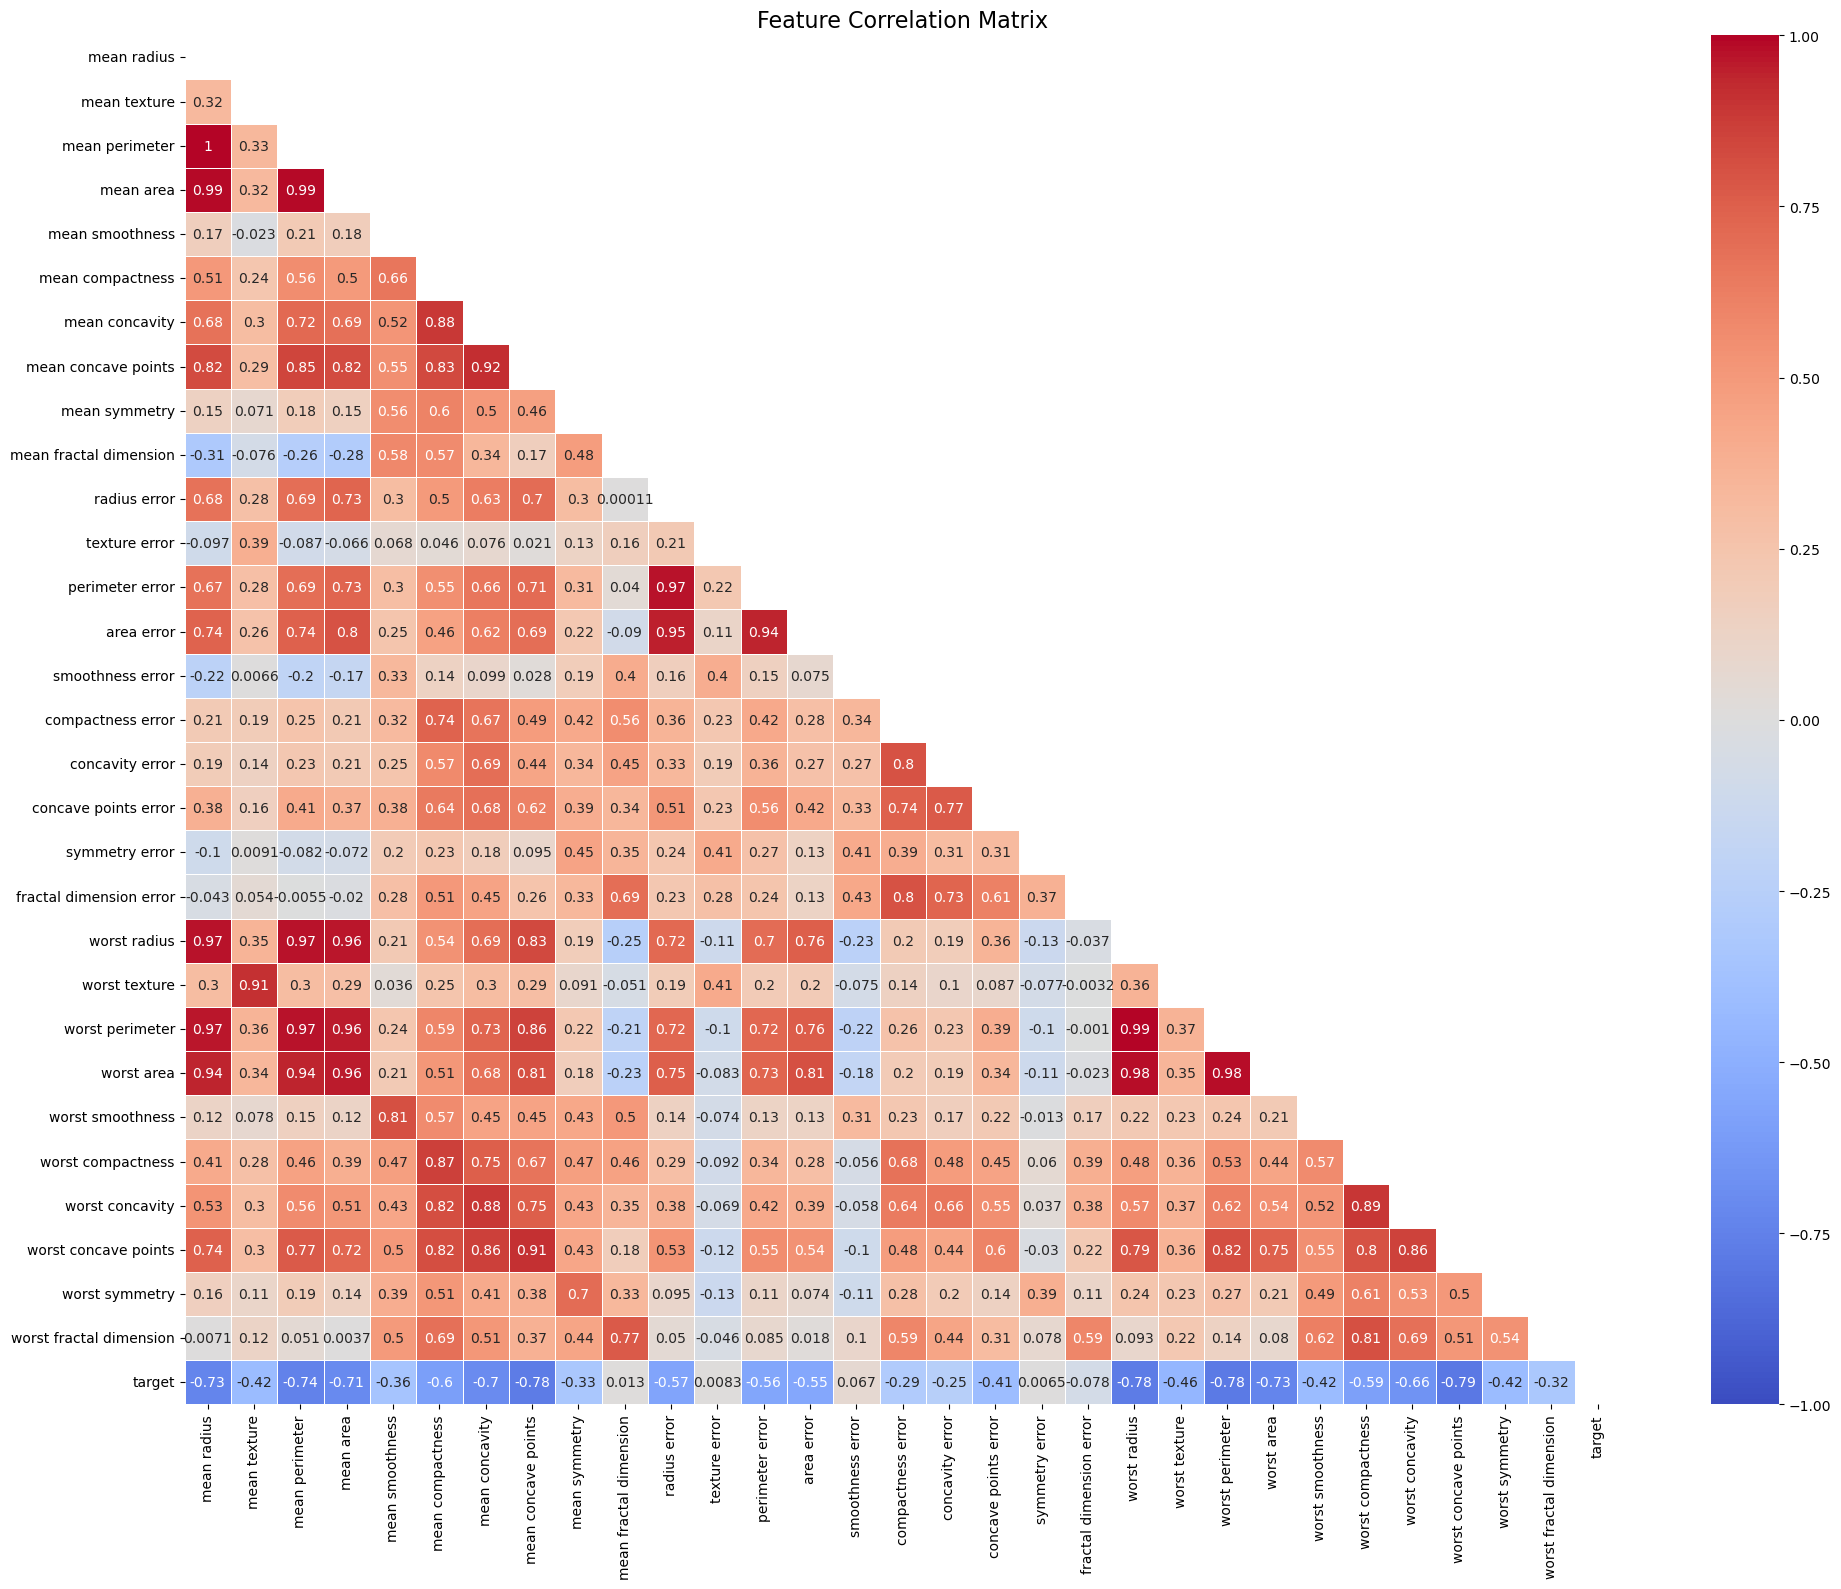

In [17]:
# Visualize the correlation between features
plt.figure(figsize=(20, 16))
correlation_matrix = df.corr()
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap='coolwarm', 
            linewidths=0.5, vmin=-1, vmax=1)
plt.title('Feature Correlation Matrix', fontsize=16)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

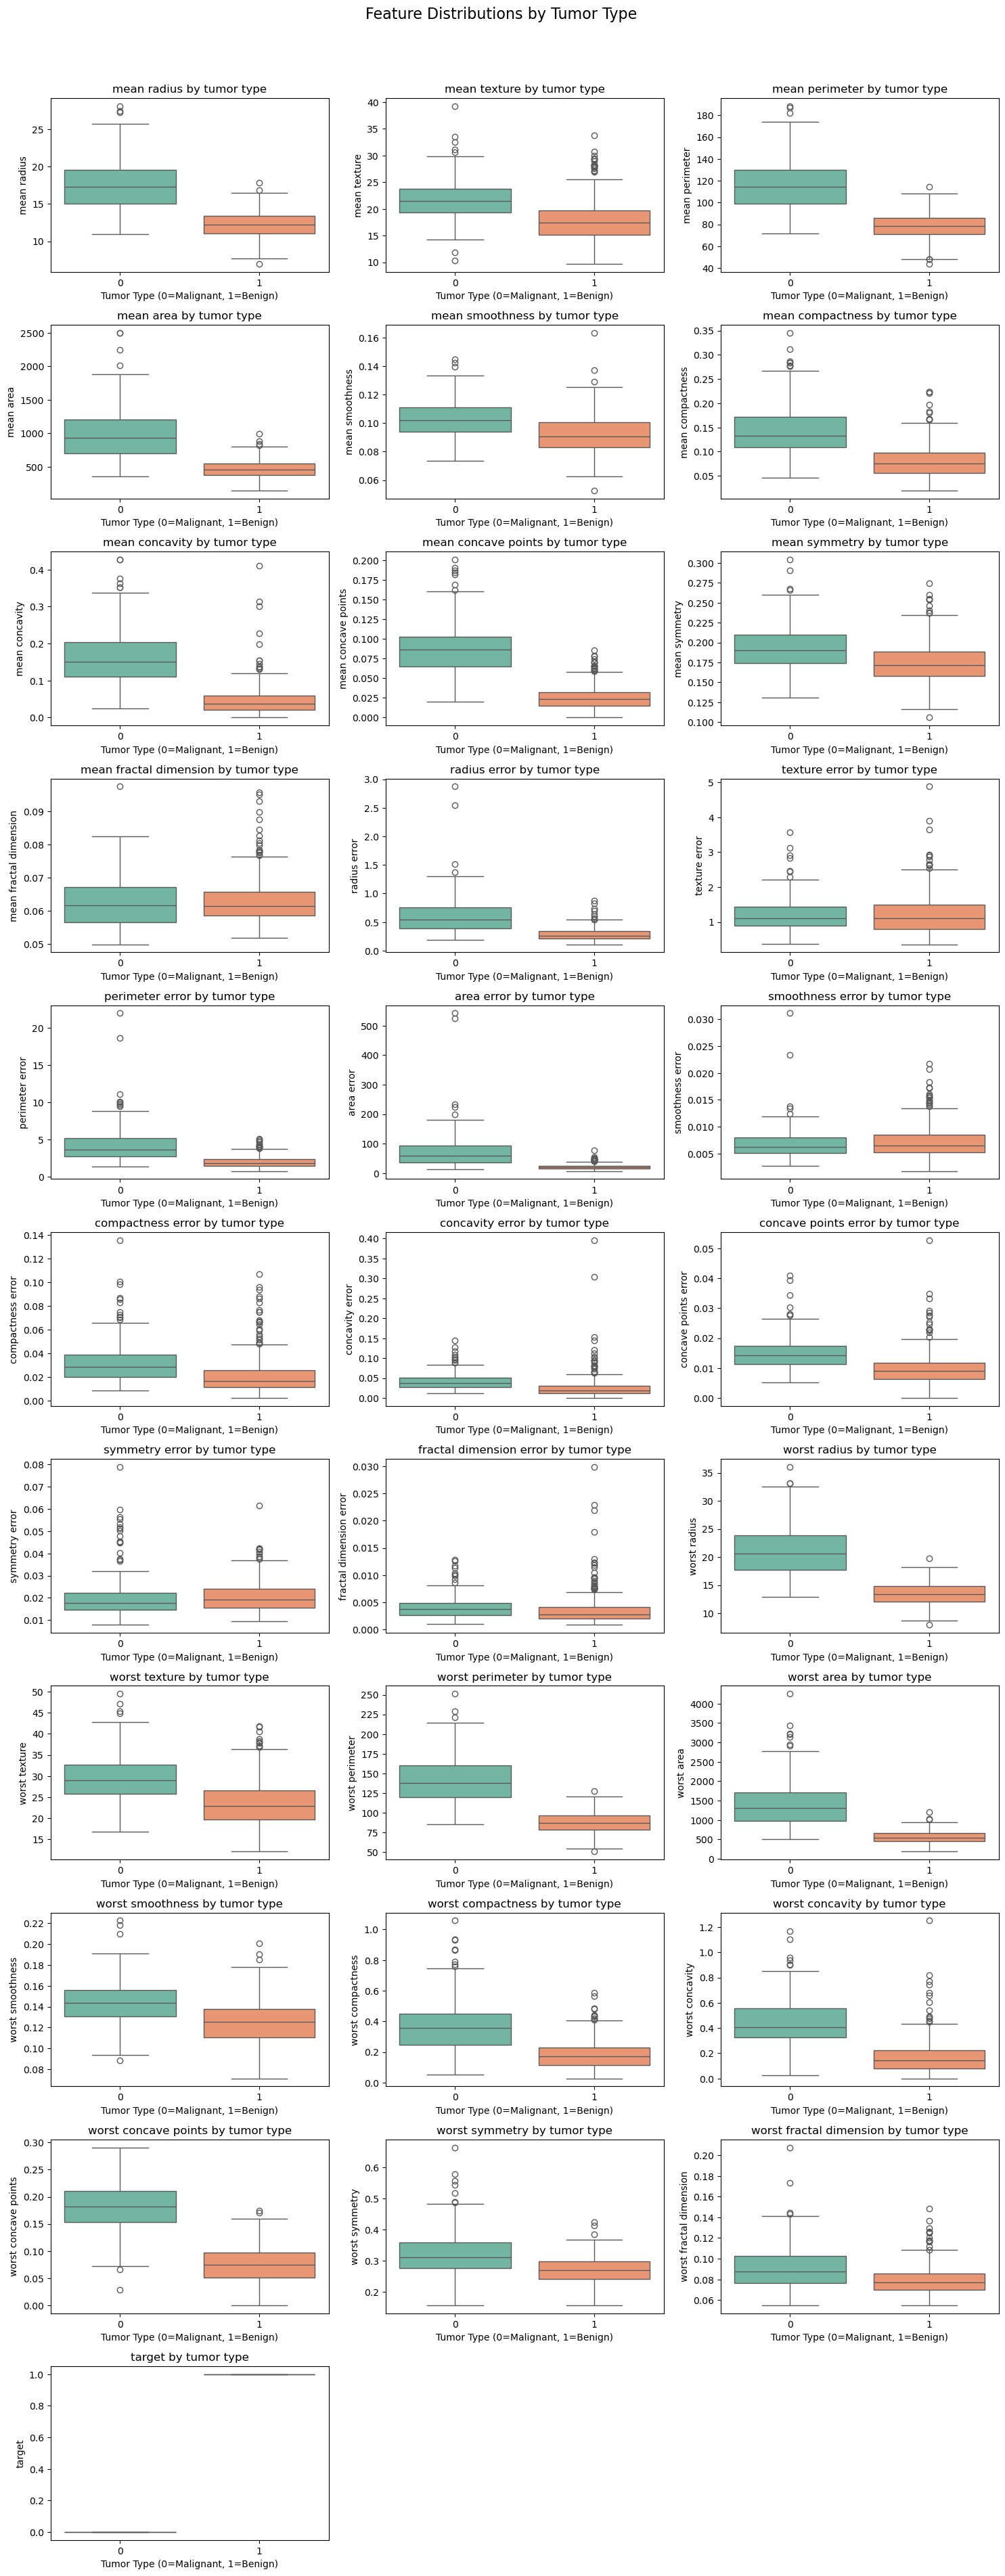

In [50]:
# Compare feature distributions between malignant and benign tumors
# Select a few important features
selected_features = ['mean radius', 'mean texture', 'mean perimeter', 'mean area', 
                     'mean smoothness', 'mean compactness']

plt.figure(figsize=(15, 50))
for i, feature in enumerate(df.columns.to_list()):
    plt.subplot(15, 3, i+1)
    sns.boxplot(x='target', y=feature, hue = "target", legend = False , data=df, palette='Set2')
    plt.title(f'{feature} by tumor type')
    plt.xlabel('Tumor Type (0=Malignant, 1=Benign)')
    
plt.tight_layout()
plt.suptitle('Feature Distributions by Tumor Type', y=1.02, fontsize=16)
plt.show()

<!-- Placeholder for feature distribution histograms -->
<!-- Figure 1: Histograms showing the distribution of each feature in the dataset -->

<!-- Placeholder for correlation matrix heatmap -->
<!-- Figure 2: Heatmap showing correlations between features -->

<!-- Placeholder for feature distributions by class -->
<!-- Figure 3: Boxplots showing how feature distributions differ between malignant and benign tumors -->

Now, let's define our features (X) and target (y) variables and split our data into training and testing sets:

In [52]:
# Define features (X) and target (y)
X = cancer.data  # Features as numpy array
y = cancer.target  # Target as numpy array

print("Features (X) shape:", X.shape)  # (samples, features)
print("Target (y) shape:", y.shape)    # (samples,)

Features (X) shape: (569, 30)
Target (y) shape: (569,)


In [56]:
df['target'].value_counts()

target
1    357
0    212
Name: count, dtype: int64

In [61]:
# Split data into training (80%) and testing (20%) sets
# stratify=y ensures the class distribution is maintained in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("\nData split complete:")
print("Training set shape (X_train):", X_train.shape)
print("Testing set shape (X_test):", X_test.shape)
print("\nTraining set class distribution:")
print(pd.Series(y_train).value_counts(normalize=True).round(3))
print("\nTesting set class distribution:")
print(pd.Series(y_test).value_counts(normalize=True).round(3))


Data split complete:
Training set shape (X_train): (455, 30)
Testing set shape (X_test): (114, 30)

Training set class distribution:
1    0.626
0    0.374
Name: proportion, dtype: float64

Testing set class distribution:
1    0.632
0    0.368
Name: proportion, dtype: float64


## 3.3.3 Feature Scaling

Logistic Regression benefits from feature scaling, especially when features have different ranges. We'll use StandardScaler to standardize our features:

In [17]:
# Initialize the scaler
scaler = StandardScaler()

# Fit the scaler ONLY on the training data
scaler.fit(X_train)

# Transform BOTH the training and test data using the learned parameters
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling applied using StandardScaler.")
print("\nBefore scaling (first sample, first 5 features):")
print(X_train[0, :5])
print("\nAfter scaling (first sample, first 5 features):")
print(X_train_scaled[0, :5])

Feature scaling applied using StandardScaler.

Before scaling (first sample, first 5 features):
[1.032e+01 1.635e+01 6.531e+01 3.249e+02 9.434e-02]

After scaling (first sample, first 5 features):
[-1.07200079 -0.6584246  -1.0880801  -0.93927364 -0.13593988]


In [18]:
# Verify that scaling worked as expected
print("\nMean of scaled training data (should be close to 0):")
print(np.mean(X_train_scaled, axis=0)[:5])
print("\nStandard deviation of scaled training data (should be close to 1):")
print(np.std(X_train_scaled, axis=0)[:5])


Mean of scaled training data (should be close to 0):
[-4.31742554e-15  2.24606658e-15 -7.38359313e-16  1.71779562e-16
  5.22695440e-15]

Standard deviation of scaled training data (should be close to 1):
[1. 1. 1. 1. 1.]


## 3.3.4 Model Training

Now we'll create and train our Logistic Regression model:

In [70]:
# Create a Logistic Regression model
# C=1.0 is the default inverse regularization strength (smaller C = stronger regularization)
# max_iter increased to ensure convergence
log_reg_model = LogisticRegression(random_state=42, max_iter=5000)

In [71]:
# Train the model on the SCALED training data
#log_reg_model.fit(X_train_scaled, y_train)
log_reg_model.fit(X_train, y_train)

LogisticRegression(max_iter=5000, random_state=42)

In [78]:
print("Logistic Regression model trained successfully.")
print("\nModel Information:")
print("Coefficient shape:", log_reg_model.coef_.shape)
print("Intercept:", log_reg_model.intercept_)

Logistic Regression model trained successfully.

Model Information:
Coefficient shape: (1, 30)
Intercept: [29.18156727]


In [79]:
log_reg_model.coef_

array([[ 0.80670807,  0.11201542, -0.28287087,  0.02523613, -0.16387734,
        -0.20596369, -0.4533218 , -0.24688836, -0.30240394, -0.03235329,
        -0.05748511,  1.08963129,  0.08714009, -0.09568569, -0.02173092,
         0.0523484 , -0.02824551, -0.03484949, -0.04096215,  0.01249115,
         0.08723065, -0.37523661, -0.08706431, -0.01460035, -0.31808505,
        -0.76302276, -1.32302921, -0.55139447, -0.77651631, -0.09413518]])

## 3.3.5 Making Predictions

With our trained model, we can now make predictions on the test data:

In [80]:
# Make class predictions (0 or 1) on the test set
y_pred_class = log_reg_model.predict(X_test)
# Make probability predictions for each class
# This returns the probability for each class (malignant and benign)
y_pred_proba = log_reg_model.predict_proba(X_test)

In [81]:
y_pred_proba[:10]

array([[1.00000000e+00, 3.34449107e-11],
       [3.51302647e-05, 9.99964870e-01],
       [9.49417294e-01, 5.05827063e-02],
       [3.96410003e-01, 6.03589997e-01],
       [9.99999998e-01, 2.06090574e-09],
       [1.74308002e-02, 9.82569200e-01],
       [2.99550952e-05, 9.99970045e-01],
       [9.99990081e-01, 9.91926827e-06],
       [9.99950992e-01, 4.90081576e-05],
       [1.00000000e+00, 1.44426127e-10]])

In [89]:
print("Predictions made on the test set.")
print("\nExample class predictions (first 10 samples):")
print(y_pred_class[:10])

Predictions made on the test set.

Example class predictions (first 10 samples):
[0 1 0 1 0 1 1 0 0 0 1 0 1 0 0 1 0 1 1 1 0 0 1 1 1 1 0 1 1 1 1 1 1 1 0 1 1
 1 1 0 1 1 1 0 0 1 1 1 1 0 1 1 1 1 1 1 1 0 0 1 1 1 1 1 0 1 1 1 1 1 1 1 1 0
 0 0 0 1 1 1 1 1 0 1 0 1 1 1 1 1 1 1 0 0 0 1 0 1 0 1]


In [91]:
print("\nActual labels (first 10 samples):")
print(y_test[:10])


Actual labels (first 10 samples):
[0 1 0 1 0 1 1 0 0 0]


In [92]:
print("\nExample probability predictions (first 10 samples):")
print("Format: [P(malignant), P(benign)]")
print(np.round(y_pred_proba[:10], 3))


Example probability predictions (first 10 samples):
Format: [P(malignant), P(benign)]
[[1.    0.   ]
 [0.    1.   ]
 [0.949 0.051]
 [0.396 0.604]
 [1.    0.   ]
 [0.017 0.983]
 [0.    1.   ]
 [1.    0.   ]
 [1.    0.   ]
 [1.    0.   ]]


## 3.3.6 Basic Evaluation

Let's evaluate our model using some basic metrics:

In [94]:
# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred_class)
print(f"Accuracy on Test Set: {accuracy:.4f}")

Accuracy on Test Set: 0.9649


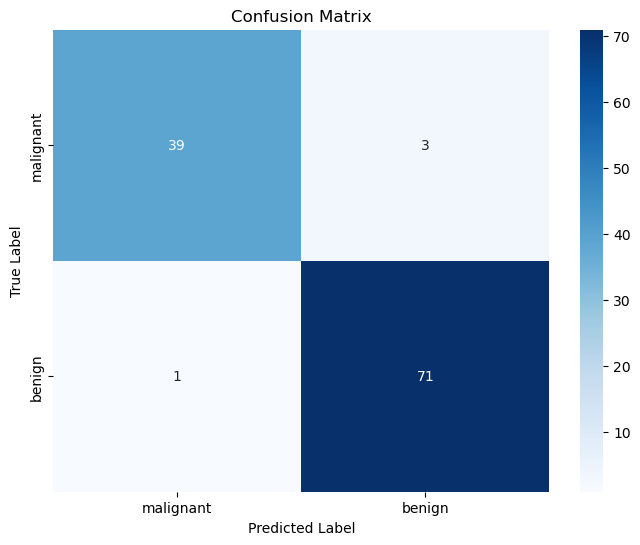

In [95]:
# Generate a confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred_class)

# Visualize the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=cancer.target_names, yticklabels=cancer.target_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [96]:
# Generate a classification report
class_report = classification_report(
    y_test, y_pred_class, target_names=cancer.target_names
)
print("\nClassification Report:")
print(class_report)


Classification Report:
              precision    recall  f1-score   support

   malignant       0.97      0.93      0.95        42
      benign       0.96      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



<!-- Placeholder for confusion matrix visualization -->
<!-- Figure 4: Confusion matrix showing true positives, false positives, true negatives, and false negatives -->

## 3.3.7 Model Interpretation

One advantage of Logistic Regression is its interpretability. Let's examine the model coefficients to understand which features are most influential in making predictions:

In [106]:
# Create a DataFrame of feature names and their corresponding coefficients
coef_df = pd.DataFrame({
    'Feature': cancer.feature_names,
    'Coefficient': log_reg_model.coef_[0]
})

# Sort by absolute coefficient value to find most influential features
coef_df = coef_df.reindex(coef_df['Coefficient'].abs().sort_values(ascending=False).index)

print("Top 10 most influential features:")
print(coef_df.head(30))

Top 10 most influential features:
                    Feature  Coefficient
26          worst concavity    -1.323029
11            texture error     1.089631
0               mean radius     0.806708
28           worst symmetry    -0.776516
25        worst compactness    -0.763023
27     worst concave points    -0.551394
6            mean concavity    -0.453322
21            worst texture    -0.375237
24         worst smoothness    -0.318085
8             mean symmetry    -0.302404
2            mean perimeter    -0.282871
7       mean concave points    -0.246888
5          mean compactness    -0.205964
4           mean smoothness    -0.163877
1              mean texture     0.112015
13               area error    -0.095686
29  worst fractal dimension    -0.094135
20             worst radius     0.087231
12          perimeter error     0.087140
22          worst perimeter    -0.087064
10             radius error    -0.057485
15        compactness error     0.052348
18           symmetry e

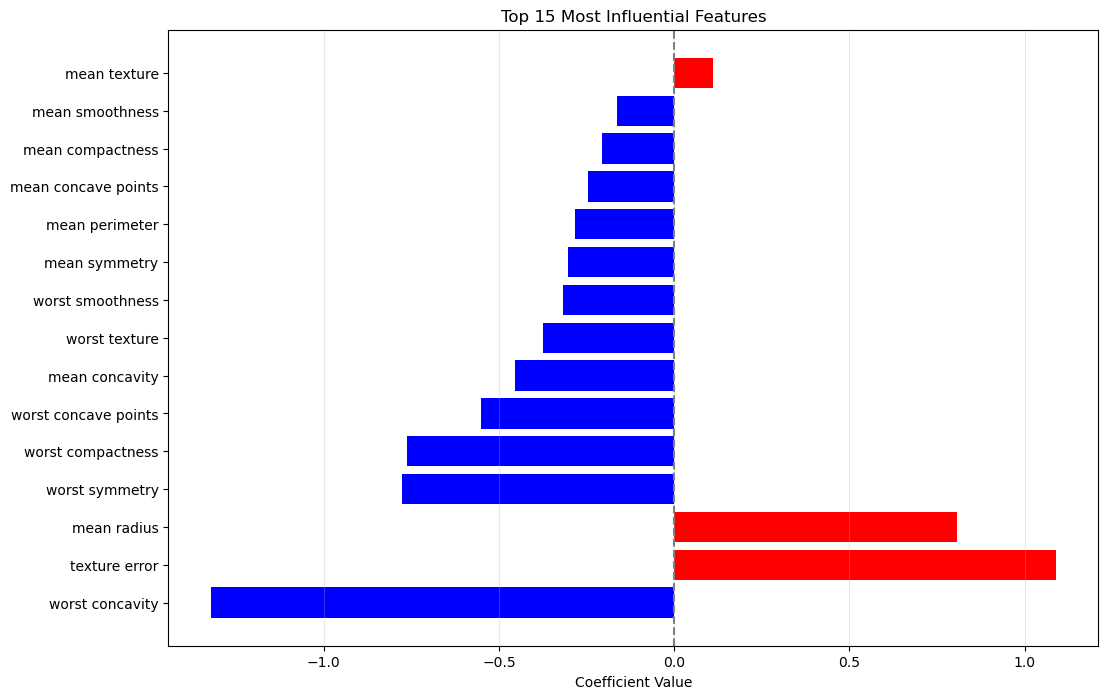

In [100]:
# Visualize the top 15 feature coefficients
plt.figure(figsize=(12, 8))
top_15 = coef_df.head(15)
colors = ['blue' if c < 0 else 'red' for c in top_15['Coefficient']]
plt.barh(range(len(top_15)), top_15['Coefficient'], color=colors)
plt.yticks(range(len(top_15)), top_15['Feature'])
plt.xlabel('Coefficient Value')
plt.title('Top 15 Most Influential Features')
plt.axvline(x=0, color='gray', linestyle='--')
plt.grid(axis='x', alpha=0.3)
plt.show()

In [102]:
# Interpretation: 
print("\nInterpretation:")
print("- Features with positive coefficients (red) increase the probability of a tumor being classified as benign (class 1)")
print("- Features with negative coefficients (blue) decrease the probability of a tumor being classified as benign (or increase the probability of it being malignant)")
print("- The magnitude of the coefficient indicates how strongly that feature influences the prediction")


Interpretation:
- Features with positive coefficients (red) increase the probability of a tumor being classified as benign (class 1)
- Features with negative coefficients (blue) decrease the probability of a tumor being classified as benign (or increase the probability of it being malignant)
- The magnitude of the coefficient indicates how strongly that feature influences the prediction


<!-- Placeholder for feature importance visualization -->
<!-- Figure 5: Bar chart showing the top 15 most influential features and their coefficient values -->

## 3.3.8 Visualization of Decision Boundary

Visualizing the decision boundary in 30-dimensional space is challenging. Let's use the top 2 most influential features to create a simplified model and visualize its decision boundary:

In [103]:
# Get the top 2 most influential features
top_2_features = coef_df.head(2)['Feature'].values
feature_indices = [list(cancer.feature_names).index(f) for f in top_2_features]

# Create a simplified dataset with just these 2 features
X_simple = cancer.data[:, feature_indices]
feature_names_simple = [cancer.feature_names[i] for i in feature_indices]

# Split the simplified dataset
X_train_simple, X_test_simple, y_train_simple, y_test_simple = train_test_split(
    X_simple, cancer.target, test_size=0.2, random_state=42, stratify=cancer.target
)

# Scale the simplified dataset
scaler_simple = StandardScaler()
X_train_simple_scaled = scaler_simple.fit_transform(X_train_simple)
X_test_simple_scaled = scaler_simple.transform(X_test_simple)

# Train a new model on the simplified dataset
log_reg_simple = LogisticRegression(random_state=42)
log_reg_simple.fit(X_train_simple_scaled, y_train_simple)

# Evaluate the simplified model
y_pred_simple = log_reg_simple.predict(X_test_simple_scaled)
accuracy_simple = accuracy_score(y_test_simple, y_pred_simple)
print(f"Accuracy of simplified model (using only top 2 features): {accuracy_simple:.4f}")

Accuracy of simplified model (using only top 2 features): 0.7982


C:\Users\solom\AppData\Local\Temp\ipykernel_2704\3299133908.py:33: UserWarning: The following kwargs were not used by contour: 'label'
  plt.contour(xx, yy, Z_proba, [0.5], colors='k', linewidths=2,


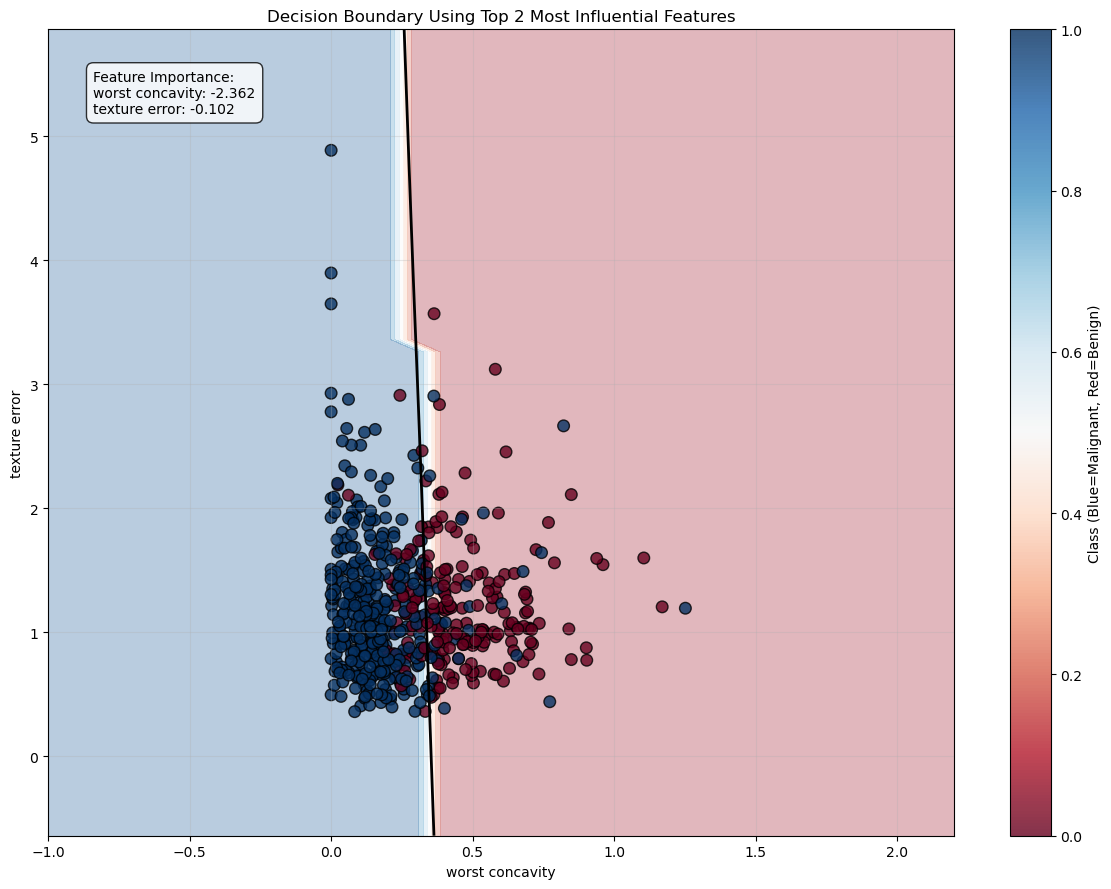

In [104]:
# Create a meshgrid to visualize the decision boundary
def plot_decision_boundary(X, y, model, scaler, feature_names):
    # Create a meshgrid
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                         np.arange(y_min, y_max, 0.1))
    
    # Scale the meshgrid
    grid_points = np.c_[xx.ravel(), yy.ravel()]
    grid_points_scaled = scaler.transform(grid_points)
    
    # Make predictions on the meshgrid
    Z = model.predict(grid_points_scaled)
    Z = Z.reshape(xx.shape)
    
    # Plot the decision boundary
    plt.figure(figsize=(12, 9))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='RdBu')
    
    # Plot the data points
    scatter = plt.scatter(X[:, 0], X[:, 1], c=y, cmap='RdBu', 
                         edgecolor='k', s=70, alpha=0.8)
    
    plt.xlabel(feature_names[0])
    plt.ylabel(feature_names[1])
    plt.title('Decision Boundary Using Top 2 Most Influential Features')
    plt.colorbar(scatter, label='Class (Blue=Malignant, Red=Benign)')
    
    # Add the decision boundary as a solid line
    Z_proba = model.predict_proba(grid_points_scaled)[:, 1]
    Z_proba = Z_proba.reshape(xx.shape)
    plt.contour(xx, yy, Z_proba, [0.5], colors='k', linewidths=2, 
                linestyles='solid', label='Decision Boundary (0.5 threshold)')
    
    # Add feature importance information
    coefs = model.coef_[0]
    plt.annotate(f'Feature Importance:\n{feature_names[0]}: {coefs[0]:.3f}\n{feature_names[1]}: {coefs[1]:.3f}',
                xy=(0.05, 0.95), xycoords='axes fraction',
                bbox=dict(boxstyle="round,pad=0.5", fc="white", alpha=0.8),
                va='top')
    
    plt.grid(alpha=0.3)
    plt.tight_layout()
    return plt

# Plot the decision boundary
plot_decision_boundary(X_simple, cancer.target, log_reg_simple, scaler_simple, feature_names_simple)
plt.show()

<!-- Placeholder for decision boundary visualization -->
<!-- Figure 6: Decision boundary visualization using the top 2 most influential features -->

## 3.3.9 Experimenting with Thresholds

Let's experiment with different decision thresholds to understand their impact on predictions:

In [41]:
# Function to evaluate predictions at different thresholds
def evaluate_threshold(y_true, y_proba, threshold):
    """Evaluate model predictions using a custom threshold."""
    y_pred = (y_proba >= threshold).astype(int)
    
    # Calculate metrics
    acc = accuracy_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    
    # Calculate additional metrics
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0  # True Positive Rate (Recall)
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0  # True Negative Rate
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    f1 = 2 * (precision * sensitivity) / (precision + sensitivity) if (precision + sensitivity) > 0 else 0
    
    return {
        'threshold': threshold,
        'accuracy': acc,
        'sensitivity': sensitivity,
        'specificity': specificity,
        'precision': precision,
        'f1_score': f1,
        'true_negatives': tn,
        'false_positives': fp,
        'false_negatives': fn,
        'true_positives': tp
    }

# Get probability predictions for the benign class (class 1)
y_proba_benign = log_reg_model.predict_proba(X_test)[:, 1]

In [42]:
y_proba_benign

array([3.34449107e-11, 9.99964870e-01, 5.05827063e-02, 6.03589997e-01,
       2.06090574e-09, 9.82569200e-01, 9.99970045e-01, 9.91926827e-06,
       4.90081576e-05, 1.44426127e-10, 9.98628342e-01, 4.87592956e-03,
       9.99104906e-01, 1.11342771e-05, 5.72839626e-04, 9.39154193e-01,
       2.20322484e-01, 9.78551151e-01, 9.98564708e-01, 9.79305134e-01,
       3.86618075e-03, 1.24112111e-02, 9.99659230e-01, 9.99242942e-01,
       9.71141475e-01, 9.35670518e-01, 4.21365934e-13, 9.94474583e-01,
       9.98491895e-01, 9.96673880e-01, 9.65575098e-01, 9.99823164e-01,
       9.62484755e-01, 9.99291821e-01, 2.38937120e-06, 7.28695742e-01,
       9.99307002e-01, 9.99614938e-01, 8.74836172e-01, 4.15329316e-07,
       9.99593582e-01, 9.99696008e-01, 9.52225360e-01, 3.61154528e-13,
       2.72120285e-03, 5.06321861e-01, 9.99995589e-01, 9.99957119e-01,
       9.81186145e-01, 1.38265129e-03, 9.97903241e-01, 5.56646880e-01,
       9.99875469e-01, 7.06804208e-01, 9.88341710e-01, 9.98435371e-01,
      

In [43]:
# Evaluate at different thresholds
thresholds = [0.1, 0.3, 0.5, 0.7, 0.9]
threshold_results = []

for threshold in thresholds:
    results = evaluate_threshold(y_test, y_proba_benign, threshold)
    threshold_results.append(results)
    print(f"\nResults with threshold = {threshold}:")
    print(f"  Accuracy: {results['accuracy']:.4f}")
    print(f"  Sensitivity (TPR): {results['sensitivity']:.4f}")
    print(f"  Specificity (TNR): {results['specificity']:.4f}")
    print(f"  Precision: {results['precision']:.4f}")
    print(f"  F1 Score: {results['f1_score']:.4f}")
    print(f"  Confusion Matrix: [TN: {results['true_negatives']}, FP: {results['false_positives']}, FN: {results['false_negatives']}, TP: {results['true_positives']}]")


Results with threshold = 0.1:
  Accuracy: 0.9474
  Sensitivity (TPR): 1.0000
  Specificity (TNR): 0.8571
  Precision: 0.9231
  F1 Score: 0.9600
  Confusion Matrix: [TN: 36, FP: 6, FN: 0, TP: 72]

Results with threshold = 0.3:
  Accuracy: 0.9561
  Sensitivity (TPR): 0.9861
  Specificity (TNR): 0.9048
  Precision: 0.9467
  F1 Score: 0.9660
  Confusion Matrix: [TN: 38, FP: 4, FN: 1, TP: 71]

Results with threshold = 0.5:
  Accuracy: 0.9649
  Sensitivity (TPR): 0.9861
  Specificity (TNR): 0.9286
  Precision: 0.9595
  F1 Score: 0.9726
  Confusion Matrix: [TN: 39, FP: 3, FN: 1, TP: 71]

Results with threshold = 0.7:
  Accuracy: 0.9386
  Sensitivity (TPR): 0.9444
  Specificity (TNR): 0.9286
  Precision: 0.9577
  F1 Score: 0.9510
  Confusion Matrix: [TN: 39, FP: 3, FN: 4, TP: 68]

Results with threshold = 0.9:
  Accuracy: 0.9035
  Sensitivity (TPR): 0.8472
  Specificity (TNR): 1.0000
  Precision: 1.0000
  F1 Score: 0.9173
  Confusion Matrix: [TN: 42, FP: 0, FN: 11, TP: 61]


In [44]:
# Create a DataFrame for easier visualization
results_df = pd.DataFrame(threshold_results)

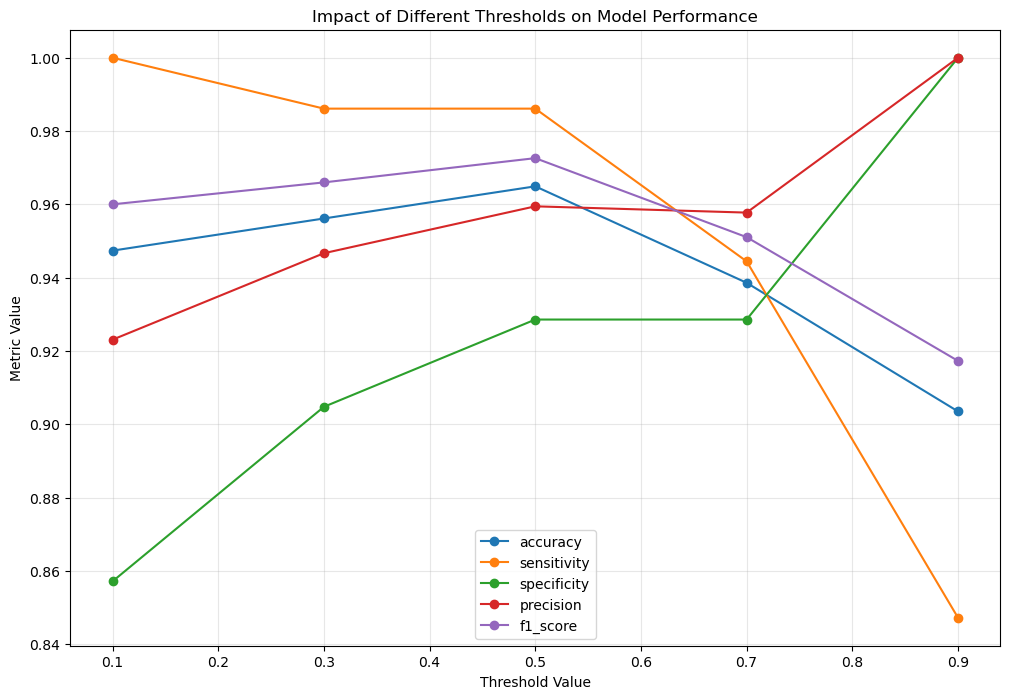

In [45]:
# Visualize how metrics change with different thresholds
plt.figure(figsize=(12, 8))
metrics_to_plot = ['accuracy', 'sensitivity', 'specificity', 'precision', 'f1_score']
for metric in metrics_to_plot:
    plt.plot(results_df['threshold'], results_df[metric], marker='o', label=metric)

plt.xlabel('Threshold Value')
plt.ylabel('Metric Value')
plt.title('Impact of Different Thresholds on Model Performance')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

In [46]:
# Highlight the threshold with the best F1 score
best_f1_idx = results_df['f1_score'].idxmax()
best_threshold = results_df.loc[best_f1_idx, 'threshold']
print(f"\nBest threshold based on F1 score: {best_threshold}")
print(f"Metrics at this threshold:")
for metric in metrics_to_plot:
    print(f"  {metric}: {results_df.loc[best_f1_idx, metric]:.4f}")


Best threshold based on F1 score: 0.5
Metrics at this threshold:
  accuracy: 0.9649
  sensitivity: 0.9861
  specificity: 0.9286
  precision: 0.9595
  f1_score: 0.9726


<!-- Placeholder for threshold impact visualization -->
<!-- Figure 7: Line chart showing how different metrics change with different threshold values -->

> **Mini-Challenge**: Try experimenting with different regularization strengths (C parameter) in the LogisticRegression model and observe how it affects the model's performance and coefficients. Does stronger regularization lead to better or worse performance on this dataset?

In [39]:
# Template code for mini-challenge
# Try different values of C (inverse regularization strength)
# Smaller C = stronger regularization
regularization_values = [0.001, 0.01, 0.1, 1, 10, 100]

# Your code here:
# 1. Loop through regularization values
# 2. Train a model with each value
# 3. Evaluate and compare results

## Summary

In this lab, we:

1. **Loaded and explored** the Breast Cancer Wisconsin dataset
2. **Prepared the data** by splitting it into training and test sets
3. **Applied feature scaling** to improve model performance
4. **Trained a Logistic Regression model** for binary classification
5. **Made predictions** on the test set (both class labels and probabilities)
6. **Evaluated the model** using accuracy, confusion matrix, and classification report
7. **Interpreted the model** by examining feature coefficients
8. **Visualized the decision boundary** using the top 2 most influential features
9. **Experimented with different thresholds** to understand their impact on predictions

### Key Takeaways:

1. Logistic Regression is effective for binary classification problems and provides interpretable results.
2. Feature scaling is important for Logistic Regression to ensure all features contribute appropriately.
3. The coefficients reveal which features are most influential in making predictions.
4. The decision threshold can be adjusted based on the specific requirements of the problem (e.g., prioritizing sensitivity over specificity).
5. Even with just the top 2 features, we can achieve reasonable performance, demonstrating the power of feature selection.

In the next session, we'll dive deeper into evaluation metrics for classification models and learn more advanced techniques for model assessment and selection.